# Summary Statistics for Christchurch AirBnB data
This notebook is intended to find the summary statistics for the Christchurch AirBnB dataset using the merged dataset created in the Airbnb chch base workflow. 

Version history:

Initial release by Leland on 11-Aug-26; ready for review

# Data up load Instructions
Download listing.csv files from https://insideairbnb.com/get-the-data/ for New Zealand, but label them with the following filename convention:

listing-X.csv

Where X is a serially increasing number starting from 0 for the NEWEST file. Save the csv files to a folder named 'data' located on the root of the project.

IMPORTANT: refer to the companion "AirBnB_date_lookup.csv" file to make sure the file names are aligned with the dates listed. Unfortunately, this is a manual process as scraping the webpage is too much effort for this project.

In [1]:
# Preparing imports
import pandas as pd
import matplotlib.pyplot as plt 


In [2]:
# Checking lookup table

# Importing the date lookup table
lookup = pd.read_csv("../output_data/AirBnB_date_lookup.csv")
lookup

,name,year_month
0,listings-0.csv,2026-6
1,listings-1.csv,2026-5
2,listings-2.csv,2026-4
3,listings-3.csv,2026-3
4,listings-4.csv,2026-2
5,listings-5.csv,2026-1
6,listings-6.csv,2025-12
7,listings-7.csv,2025-11
8,listings-8.csv,2025-10


In [3]:
# Preparing loop to go through all the files in the lookup list and extract all the Chch entries and add them to a single df

# First, initialising empty object to append data to
merged_data = []

# Actual loop over the files and appending chch data to the object
for row in lookup.itertuples(index = False): # using itertuples to go over rows instead of cols (the default)
    df = pd.read_csv(f"../data/{row.name}") # getting the file name from the lookup table
    df = df[df["neighbourhood_group"] == "Christchurch City"]
    df["year_month"] = row.year_month # getting year-month from the lookup table
    merged_data.append(df)

# Finally merging via concat
merged_data = pd.concat(merged_data, ignore_index = True)

merged_data

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,year_month
0,968224198043666870,Room,516048910.0,Heer,Christchurch City,Innes Ward,-43.498150,172.650540,Private room,64.0,1.0,0,NaN,NaN,1.0,89,0,NaN,2026-6
1,24742386,Garden Studio With Ensuite (Breakfast included),43654083.0,Kathy,Christchurch City,Papanui Ward,-43.504070,172.596070,Entire home/apt,172.0,1.0,205,2026-05-19,2.31,1.0,241,36,NaN,2026-6
2,1654821509215926144,Papanui Oasis Entire House,754856789.0,Jonathan Allan,Christchurch City,Papanui Ward,-43.489540,172.614080,Entire home/apt,230.0,1.0,5,2026-05-16,2.24,1.0,335,5,NaN,2026-6
3,7403587,Warm Cosy Quiet Home Semi Rural,38795211.0,Wendy,Christchurch City,Halswell Ward,-43.576050,172.546860,Private room,143.0,1.0,0,NaN,NaN,1.0,263,0,NaN,2026-6
4,22570965,One Bedroom Apartment,44728588.0,Anita Marie,Christchurch City,Papanui Ward,-43.486060,172.616880,Hotel room,202.0,1.0,3,2022-04-27,0.03,6.0,342,0,NaN,2026-6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28790,1161213044338512029,Bright & Airy on Tuam - 2 Beds Apartment,202585247.0,Ohana,Christchurch City,Central Ward,-43.535478,172.635144,Entire home/apt,147.0,1.0,133,2025-10-01,7.95,121.0,35,90,NaN,2025-10
28791,1180667042629129011,Central city sunsets - Warm! Modern! Quiet!,482671075.0,Paula Corinne,Christchurch City,Central Ward,-43.537523,172.638452,Entire home/apt,268.0,1.0,49,2025-09-24,3.15,124.0,285,42,NaN,2025-10
28792,1424846609710116983,Upper floor studio 1 bed 1 bath with sofa bed,482671075.0,Paula Corinne,Christchurch City,Central Ward,-43.537800,172.641679,Entire home/apt,126.0,1.0,17,2025-09-27,3.75,124.0,239,17,NaN,2025-10
28793,1395109904560781257,Cozy guesthouse in casebrook,433251428.0,Donna,Christchurch City,Harewood Ward,-43.478480,172.602470,Entire home/apt,102.0,1.0,3,2025-08-16,0.51,1.0,160,3,NaN,2025-10


In [4]:
# Finally exporting the csv out back to ../data
merged_data.to_csv("../data/AirBnB_all_chch.csv", index = False)

# Summary Statistics and Missing Values 

In [5]:
# Summary statistics 
merged_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,2.879500e+04,2.879500e+04,28795.000000,28795.000000,18128.000000,28758.000000,28795.000000,26168.000000,28795.000000,28795.000000,28795.000000,0.0
mean,9.030627e+17,1.988281e+15,-43.555493,172.661295,260.199636,1.787537,70.391700,2.350719,58.297031,203.804792,18.996909,NaN
std,5.945297e+17,5.782999e+16,0.076280,0.096666,943.721501,5.509471,120.513512,2.185566,188.532710,112.282973,23.502198,NaN
min,2.040500e+05,5.738200e+04,-43.867510,172.433375,27.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,NaN
25%,5.237109e+07,6.395537e+07,-43.556188,172.616910,140.000000,1.000000,5.000000,0.760000,1.000000,109.000000,2.000000,NaN
50%,1.089973e+18,1.721473e+08,-43.532410,172.639580,205.000000,1.000000,26.000000,1.700000,3.000000,225.000000,10.000000,NaN
75%,1.393916e+18,4.471452e+08,-43.521706,172.659970,284.000000,2.000000,85.000000,3.330000,47.000000,302.000000,27.000000,NaN
max,1.709886e+18,1.704737e+18,-43.416340,173.097001,43654.000000,365.000000,1584.000000,16.570000,1586.000000,365.000000,185.000000,NaN


In [12]:
# Correlation between variables 
correlation_matrix = merged_data.corr()
correlation_matrix

/var/folders/4r/f6cxr8h14nzdv3r26lrrkrwr0000gn/T/ipykernel_46992/3950051727.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = merged_data.corr()


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,1.000000,0.042165,0.132484,-0.108628,0.011926,-0.027348,-0.471499,0.090073,0.077060,-0.021154,-0.099999,NaN
host_id,0.042165,1.000000,0.019321,-0.021833,-0.004238,-0.003819,-0.017288,0.003631,-0.010202,0.006353,-0.022270,NaN
latitude,0.132484,0.019321,1.000000,-0.849859,-0.051324,-0.005412,-0.016642,0.103574,-0.184269,-0.081580,0.065336,NaN
longitude,-0.108628,-0.021833,-0.849859,1.000000,0.051495,0.005550,-0.002376,-0.108002,0.187093,0.057017,-0.072647,NaN
price,0.011926,-0.004238,-0.051324,0.051495,1.000000,0.000819,-0.033729,-0.043876,0.225258,0.028018,-0.039880,NaN
minimum_nights,-0.027348,-0.003819,-0.005412,0.005550,0.000819,1.000000,-0.043012,-0.080225,-0.012079,-0.039280,-0.076645,NaN
number_of_reviews,-0.471499,-0.017288,-0.016642,-0.002376,-0.033729,-0.043012,1.000000,0.583582,-0.089390,-0.055491,0.637491,NaN
reviews_per_month,0.090073,0.003631,0.103574,-0.108002,-0.043876,-0.080225,0.583582,1.000000,-0.080971,-0.101141,0.838314,NaN
calculated_host_listings_count,0.077060,-0.010202,-0.184269,0.187093,0.225258,-0.012079,-0.089390,-0.080971,1.000000,0.179234,-0.069040,NaN
availability_365,-0.021154,0.006353,-0.081580,0.057017,0.028018,-0.039280,-0.055491,-0.101141,0.179234,1.000000,-0.102181,NaN


# Missing Values in dataset 

In [6]:
# Missing values for each column in dataset 
missing_values = merged_data.isnull().sum()
missing_values

id                                    0
name                                  0
host_id                               0
host_name                             1
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                             10667
minimum_nights                       37
number_of_reviews                     0
last_review                        2627
reviews_per_month                  2627
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           28795
year_month                            0
dtype: int64

In [16]:
# Missingess by Percentage for each column in the dataset 
missingness_percentage = merged_data.isnull().mean()*100
missingness_percentage

id                                  0.000000
name                                0.000000
host_id                             0.000000
host_name                           0.003473
neighbourhood_group                 0.000000
neighbourhood                       0.000000
latitude                            0.000000
longitude                           0.000000
room_type                           0.000000
price                              37.044626
minimum_nights                      0.128495
number_of_reviews                   0.000000
last_review                         9.123112
reviews_per_month                   9.123112
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
license                           100.000000
year_month                          0.000000
dtype: float64

In [25]:
# Correlation between variables with missing values 
missingness = df.isna()
corr_missing = missingness.corr()
corr_missing = corr_missing.dropna(axis = 0, how = "all")
corr_missing = corr_missing.dropna(axis = 1, how = "all")
corr_missing

,price,last_review,reviews_per_month
price,1.00000,0.00738,0.00738
last_review,0.00738,1.00000,1.00000
reviews_per_month,0.00738,1.00000,1.00000


# Initial Visualization of Outliers

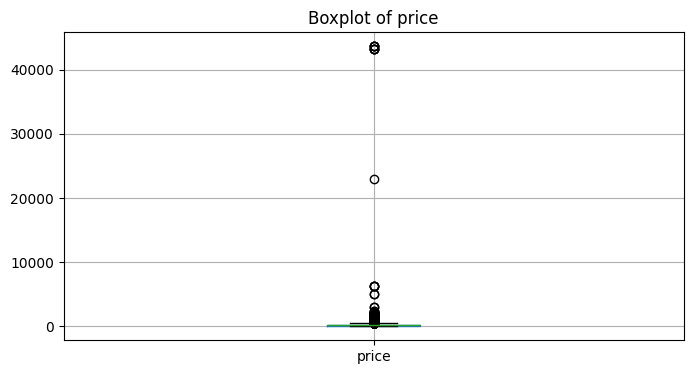

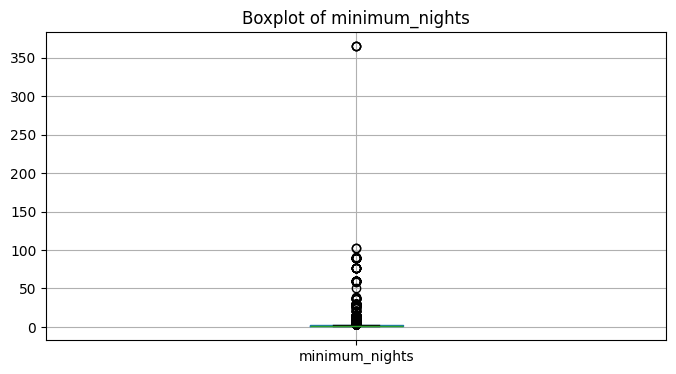

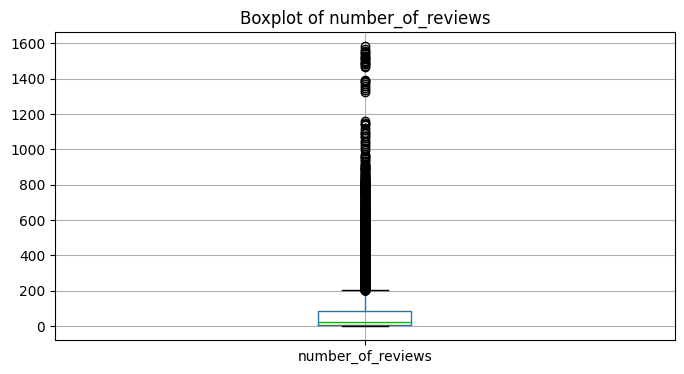

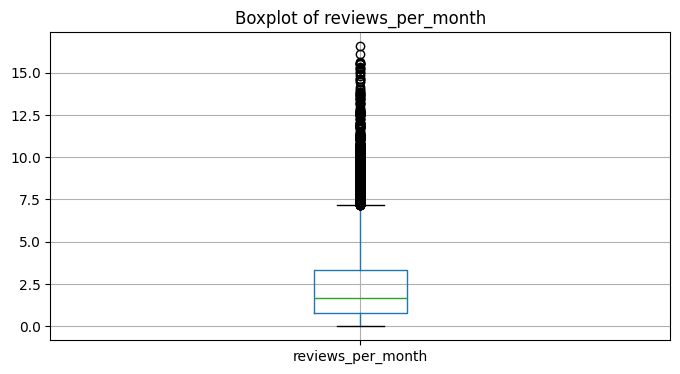

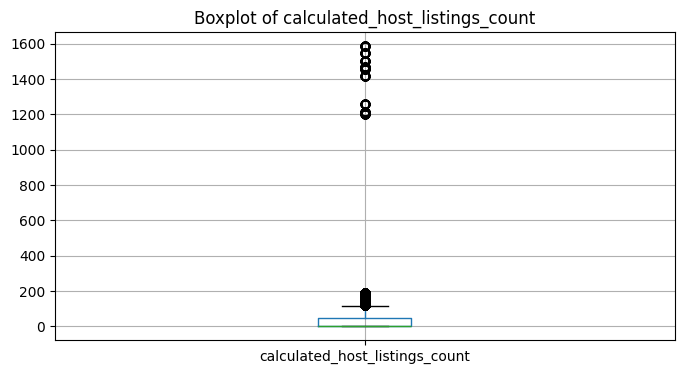

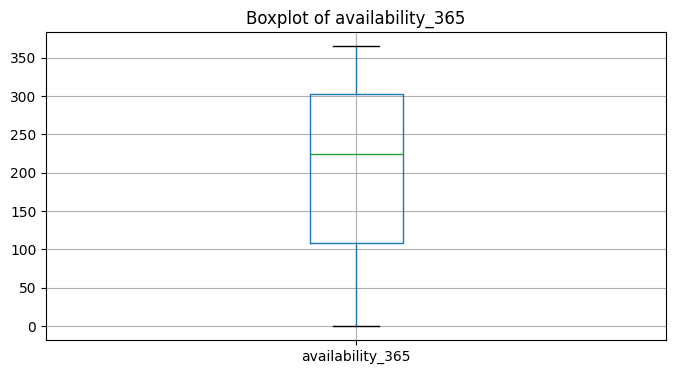

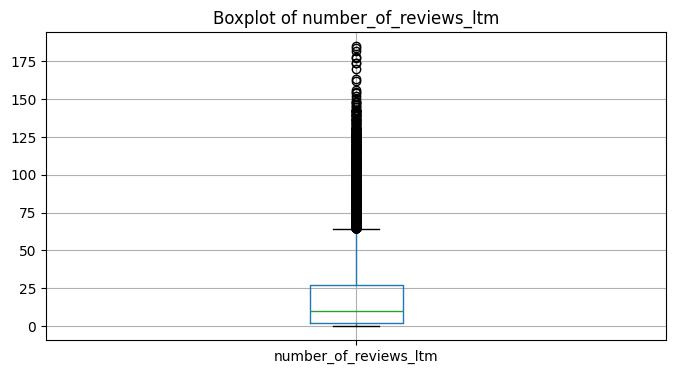

In [30]:
#removing columns that have no meaningful context for outliers 
exclude_cols = ["id", "host_id", "latitude", "longitude", "license"]

#Keeping only the numeric columns 
numeric = merged_data.select_dtypes(include = "number").columns

for col in numeric:
    if col not in exclude_cols:
        plt.figure (figsize = (8,4))
        merged_data.boxplot(column = col)
        plt.title(f"Boxplot of {col}")
        plt.show
